In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [76]:
# Dataset da Aula
np.random.seed(43)
n = 500

df = pd.DataFrame({
    "idade": np.random.randint(20, 65, n),
    "salario": np.concatenate([
        np.random.normal(1500, 400, int(n * 0.7)),
        np.random.normal(3000, 600, int(n * 0.2)),
        np.random.normal(8000, 1000, int(n * 0.1)),
    ]),
    "experiencia": np.random.randint(0, 35, n),
    "horas_semana": np.random.normal(40, 5, n).round(1),
    "satisfacao": np.random.normal(7, 1.5, n).round(1).clip(1, 10),
    "departamento": np.random.choice(["IT", "Marketing", "Vendas", "RH", "Financeiro"], n),
    "cidade": np.random.choice(["Lisboa", "Porto", "Coimbra", "Braga", "Faro"], n),
})
df["salario"] = df["salario"].round(2)

print(f"Shape: {df.shape}")
df.head()

Shape: (500, 7)


,idade,salario,experiencia,horas_semana,satisfacao,departamento,cidade
0,24,982.23,31,31.6,7.6,Financeiro,Braga
1,20,1842.08,5,41.9,7.9,Vendas,Braga
2,41,1463.03,2,37.9,6.2,IT,Faro
3,36,1851.46,28,35.7,4.8,IT,Lisboa
4,37,1618.76,34,35.0,8.2,RH,Coimbra


In [95]:
df["departamento"].unique()

<StringArray>
['Financeiro', 'Vendas', 'IT', 'RH', 'Marketing']
Length: 5, dtype: str

In [96]:
df.groupby("departamento")["salario"].mean()

departamento
Financeiro    2377.010521
IT            2518.363786
Marketing     2307.028173
RH            2566.916000
Vendas        2495.695980
Name: salario, dtype: float64

In [99]:
# O que é que define as pesoas que ganham bué dinheiro?
df_salarios_altos = df[df["salario"] > 5000]
df_salarios_altos.head(5)

,idade,salario,experiencia,horas_semana,satisfacao,departamento,cidade
450,51,7298.58,11,42.3,5.7,Marketing,Porto
451,47,8191.75,7,44.4,9.3,Marketing,Porto
452,59,9081.18,22,34.2,8.0,IT,Faro
453,57,8453.21,26,42.6,6.8,IT,Faro
454,20,9193.87,5,35.1,7.4,RH,Lisboa


In [ ]:
# Medidas de tendência Central
# 3 formas de responder à pergunta "Qual é o valor típico do salário?"

In [78]:
salarios = df["salario"]

In [79]:
# Média
media = salarios.mean()
int(media)

2451

In [80]:
# Mediana
mediana = salarios.median()
int(mediana)

1722

In [81]:
# Moda
moda = salarios.mode()[0]
int(moda)

1436

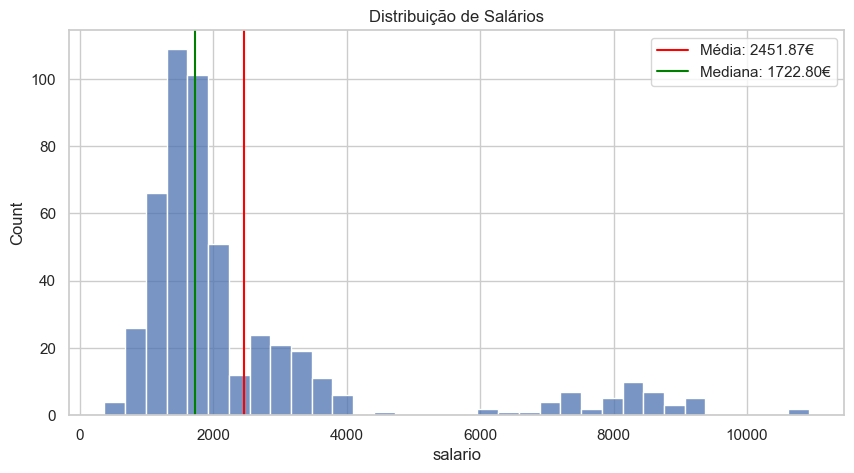

In [94]:
# Histograma
plt.figure(figsize=(10,5))
sns.histplot(salarios)
plt.axvline(media, color="red", label=f"Média: {media:.2f}€")
plt.axvline(mediana, color="green", label=f"Mediana: {mediana:.2f}€")
plt.title("Distribuição de Salários")
plt.legend()
plt.show()

In [100]:
# Medidas de Dispersão

In [101]:
# Variância e Desvio-Padrão
print(f"Variância      : {salarios.var():.2f}")
print(f"Desvio Padrão  : {salarios.std():.2f}")

Variância      : 4071797.10
Desvio Padrão  : 2017.87


In [102]:
# Range e IQR
print(f"Range          : {salarios.max() - salarios.min():.2f}")
print(f"IQR            : {salarios.quantile(0.75) - salarios.quantile(0.25):.2f}") 

Range          : 10566.20
IQR            : 1259.65


In [103]:
# Quantis e Percentis
print(f"Q1            : {salarios.quantile(0.25):.2f}")
print(f"Q2            : {salarios.quantile(0.5):.2f}")
print(f"Q3            : {salarios.quantile(0.75):.2f}")

Q1            : 1383.09
Q2            : 1722.80
Q3            : 2642.74


In [ ]:
# Skewness (assimetria) e Kurtosis (curtose)

# Skewness dos salários
print(f"Skewness dos salários: {salarios.skew():.3f}")

# Skewness Positivo: 

Skewness dos salários: 2.286


In [105]:
# Curtose dos salários
print(f"Curtose dos salários: {salarios.kurtosis():.3f}")

Curtose dos salários: 4.373
